In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings 
warnings.filterwarnings('ignore')

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                               roc_auc_score, roc_curve)
from sklearn.datasets import load_breast_cancer

sns.set_theme(style = 'darkgrid', palette = 'husl')
plt.rcParams['figure.figsize'] = (10,6)

print('All Libraries imported successfully!')

All Libraries imported successfully!


## Part1 : Daibetes Prediction

In [7]:
df_d = pd.read_csv('diabetes.csv')

In [8]:
df_d.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df_d.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
df_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [14]:
df_d.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

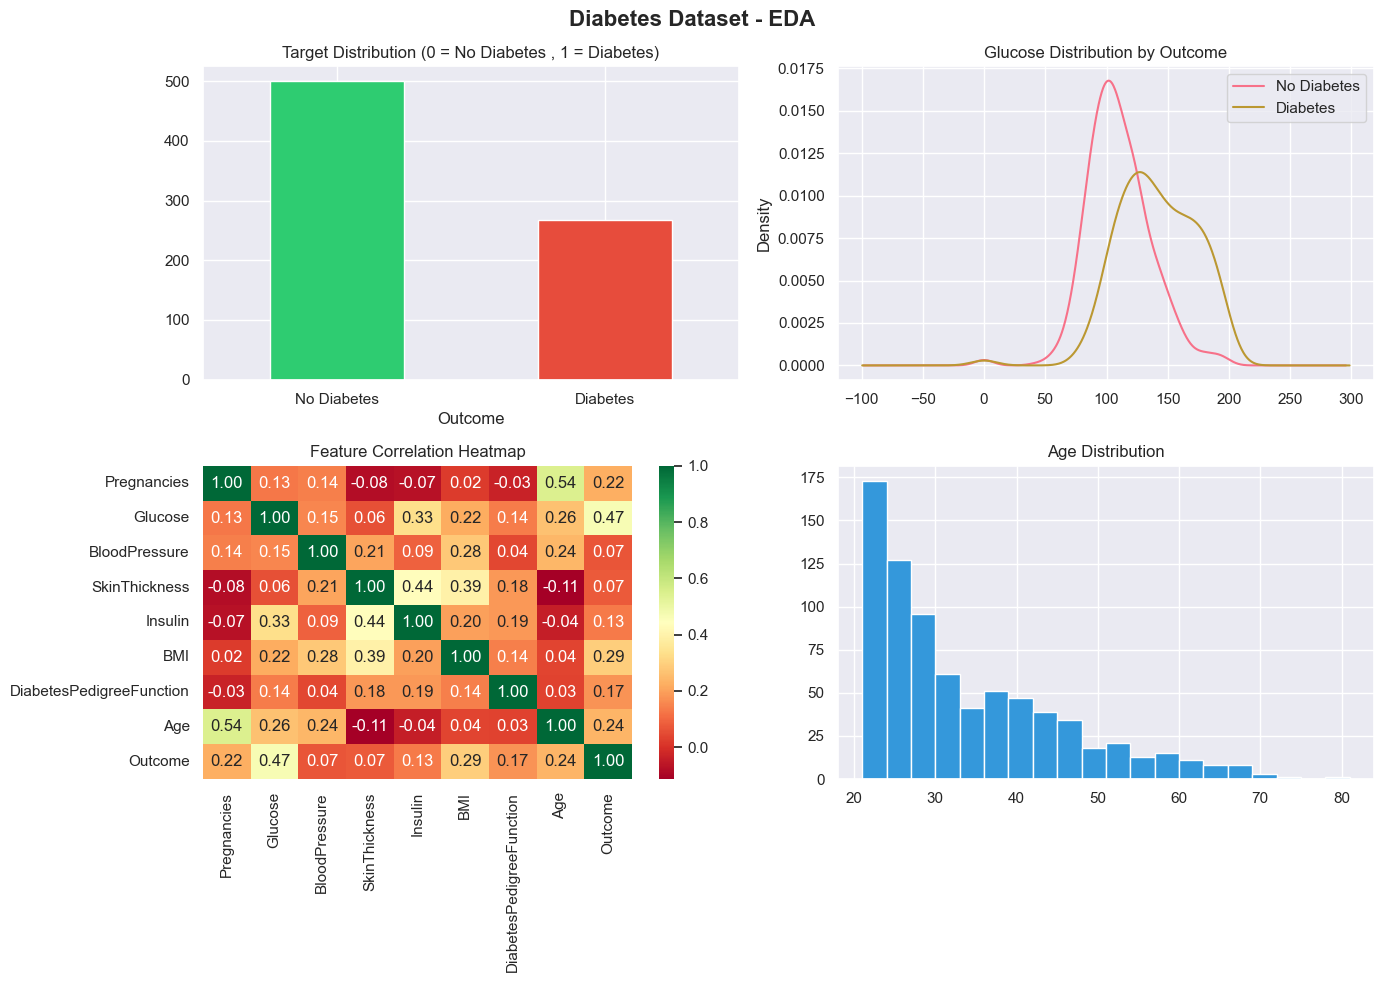

EDA Plots Saved!


In [16]:
# ── Visualizations ─
fig , axes = plt.subplots(2,2 , figsize = (14,10))
fig.suptitle('Diabetes Dataset - EDA',fontsize = 16 , fontweight = 'bold')

# Target distribution
df_d['Outcome'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Target Distribution (0 = No Diabetes , 1 = Diabetes)')
axes[0,0].set_xticklabels(['No Diabetes', 'Diabetes'],rotation = 0)

# Glucose distribution by outcome
df_d.groupby('Outcome')['Glucose'].plot(kind = 'kde', ax = axes[0,1])
axes[0,1].set_title('Glucose Distribution by Outcome')
axes[0,1].legend(['No Diabetes','Diabetes'])

#Correlation Distribution by Outcome
corr = df_d.corr()
sns.heatmap(corr, annot = True , fmt = '.2f', ax = axes[1,0], cmap='RdYlGn' )
axes[1,0].set_title('Feature Correlation Heatmap')

#Age Distribution
df_d['Age'].hist(bins = 20, ax = axes[1,1], color ='#3498db', edgecolor = 'white' )
axes[1,1].set_title('Age Distribution')

plt.tight_layout()
plt.savefig('Diabetes_EDA.png',dpi = 150, bbox_inches = 'tight')
plt.show()
print('EDA Plots Saved!')




In [21]:
#Replace 0s with NAN for column where 0 is invalid
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin' ,'BMI']
df_d[zero_cols] = df_d[zero_cols].replace(0 , np.nan)

#Fill missing values with median
df_d[zero_cols] = df_d[zero_cols].fillna(df_d[zero_cols].median())

print("Missing value handled")
print('Remaining nulls:', df_d.isnull().sum().sum())

Missing value handled
Remaining nulls: 0


In [22]:
x_d = df_d.drop('Outcome', axis=1)
y_d = df_d['Outcome']

x_train_d, x_test_d, y_train_d, y_test_d = train_test_split(
    x_d, y_d, test_size=0.2, random_state=42, stratify=y_d)

scaler_d = StandardScaler()
x_train_d_sc = scaler_d.fit_transform(x_train_d)
x_test_d_sc = scaler_d.transform(x_test_d)

print(f'Train: {x_train_d_sc.shape}, Test: {x_test_d_sc.shape}')

Train: (614, 8), Test: (154, 8)


In [24]:
# Train Multiple Models and Compare ----

In [32]:
models_d = {
    'Logistic Regression': LogisticRegression(max_iter=1000 , random_state = 42),
    'Random Forest' : RandomForestClassifier(n_estimators = 100 , random_state = 42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators = 100 , random_state = 42),
    'SVM' : SVC(probability = True , random_state = 42)
}

results_d= {}

for name , model in models_d.items():
    model.fit(x_train_d_sc , y_train_d)
    acc = accuracy_score(y_test_d , model.predict(x_test_d_sc))
    auc = roc_auc_score(y_test_d, model.predict_proba(x_test_d_sc)[:,1])
    cv  = cross_val_score(model, x_train_d_sc, y_train_d, cv=5).mean()
    results_d[name] = {'Accuracy': acc, 'AUC': auc, 'CV Score': cv}
    print(f'{name:25s} | Acc: {acc:.4f} | AUC: {auc:.4f} | CV: {cv:.4f}')

# Pick best model
best_diab_name = max(results_d, key=lambda k: results_d[k]['AUC'])
best_diab_model = models_d[best_diab_name]
print(f'\n Best Model: {best_diab_name}')    

Logistic Regression       | Acc: 0.7078 | AUC: 0.8130 | CV: 0.7818
Random Forest             | Acc: 0.7792 | AUC: 0.8179 | CV: 0.7688
Gradient Boosting         | Acc: 0.7597 | AUC: 0.8304 | CV: 0.7622
SVM                       | Acc: 0.7403 | AUC: 0.7964 | CV: 0.7688

 Best Model: Gradient Boosting


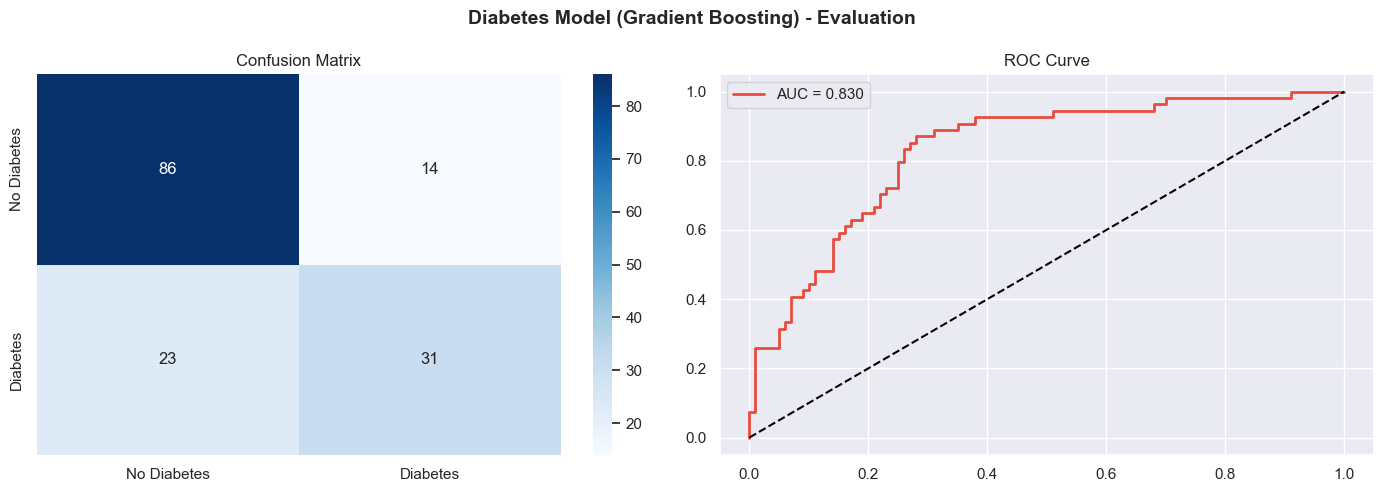

              precision    recall  f1-score   support

 No Diabetes       0.79      0.86      0.82       100
    Diabetes       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



In [34]:
# ── Confusion Matrix & ROC Curve ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Diabetes Model ({best_diab_name}) - Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test_d, best_diab_model.predict(x_test_d_sc))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes','Diabetes'], yticklabels=['No Diabetes','Diabetes'])
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_d, best_diab_model.predict_proba(x_test_d_sc)[:,1])
auc_score = roc_auc_score(y_test_d, best_diab_model.predict_proba(x_test_d_sc)[:,1])
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()
print(classification_report(y_test_d, best_diab_model.predict(x_test_d_sc),
                             target_names=['No Diabetes','Diabetes']))

In [37]:
# ── Save Diabetes Model ──
joblib.dump(best_diab_model, 'diabetes_model.pkl')
joblib.dump(scaler_d, 'diabetes_scaler.pkl')
joblib.dump(list(x_d.columns), 'diabetes_features.pkl')
print('✅ Diabetes model saved!')

✅ Diabetes model saved!


## PART 2: HEART DISEASE PREDICTION

In [39]:
df_heart = pd.read_csv('heart_cleveland_upload.csv')

In [40]:
if 'target' not in df_heart.columns:
    df_heart.columns = ['age','sex','cp','trestbps','chol','fbs','restecg',
                        'thalach','exang','oldpeak','slope','ca','thal','target']

print('Shape:', df_heart.shape)
df_heart.head()

Shape: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


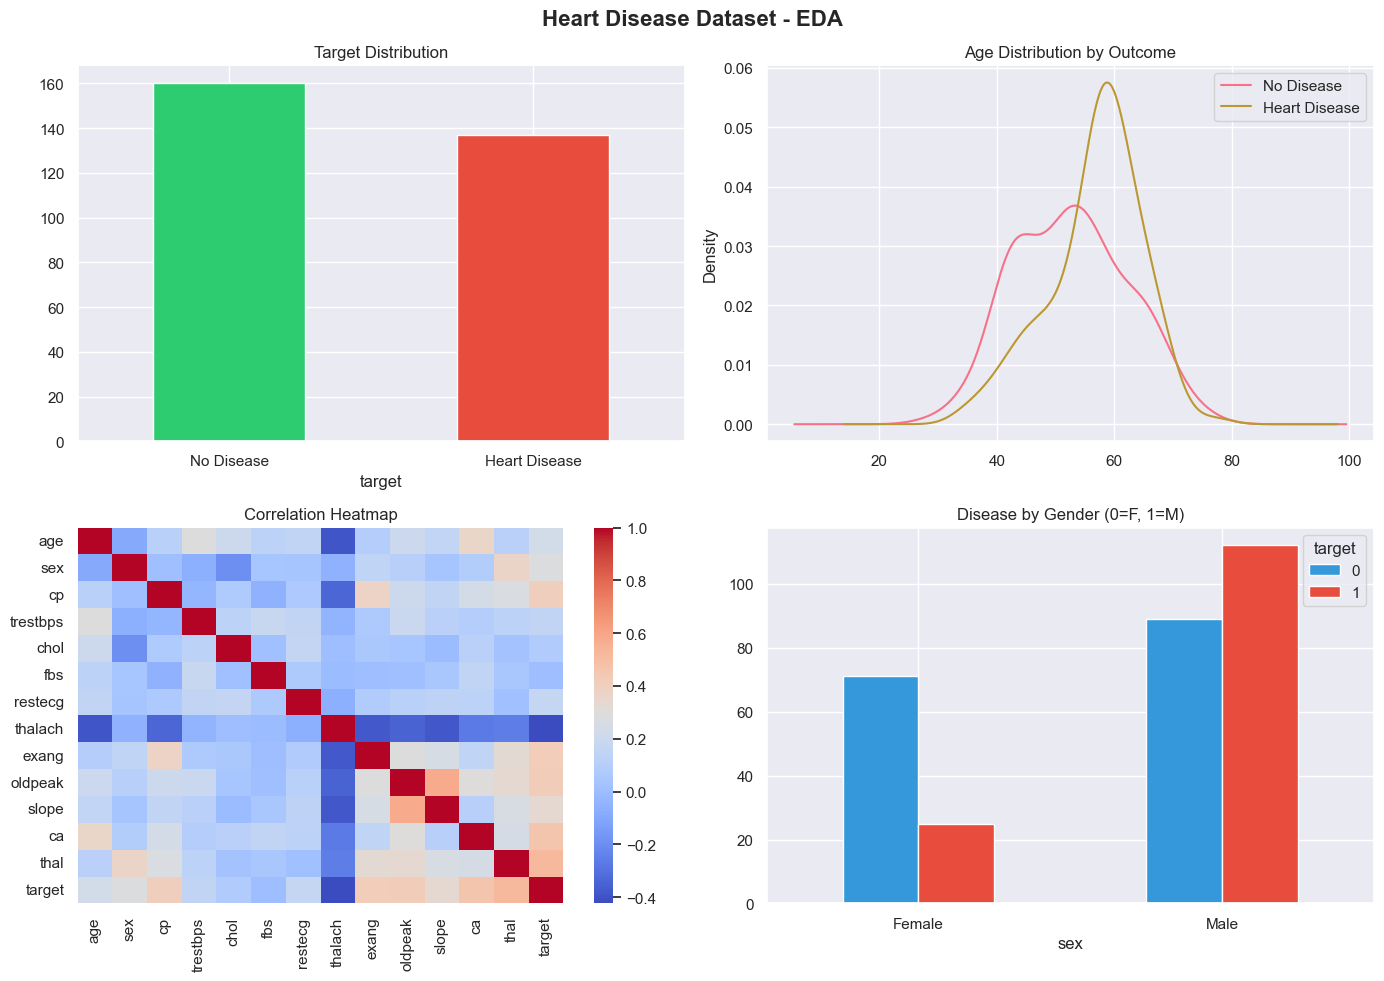

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Heart Disease Dataset - EDA', fontsize=16, fontweight='bold')

df_heart['target'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Target Distribution')
axes[0,0].set_xticklabels(['No Disease','Heart Disease'], rotation=0)

df_heart.groupby('target')['age'].plot(kind='kde', ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Outcome')
axes[0,1].legend(['No Disease', 'Heart Disease'])

sns.heatmap(df_heart.corr(), annot=False, ax=axes[1,0], cmap='coolwarm')
axes[1,0].set_title('Correlation Heatmap')

df_heart.groupby(['sex','target']).size().unstack().plot(kind='bar', ax=axes[1,1],
                                                          color=['#3498db','#e74c3c'])
axes[1,1].set_title('Disease by Gender (0=F, 1=M)')
axes[1,1].set_xticklabels(['Female','Male'], rotation=0)

plt.tight_layout()
plt.savefig('heart_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ── Preprocessing & Training ──
df_heart.dropna(inplace=True)

X_heart = df_heart.drop('target', axis=1)
y_heart = df_heart['target']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart)

scaler_h = StandardScaler()
X_train_h_sc = scaler_h.fit_transform(X_train_h)
X_test_h_sc  = scaler_h.transform(X_test_h)

models_heart = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42)
}

results_heart = {}
for name, model in models_heart.items():
    model.fit(X_train_h_sc, y_train_h)
    acc = accuracy_score(y_test_h, model.predict(X_test_h_sc))
    auc = roc_auc_score(y_test_h, model.predict_proba(X_test_h_sc)[:,1])
    cv  = cross_val_score(model, X_train_h_sc, y_train_h, cv=5).mean()
    results_heart[name] = {'Accuracy': acc, 'AUC': auc, 'CV Score': cv}
    print(f'{name:25s} | Acc: {acc:.4f} | AUC: {auc:.4f} | CV: {cv:.4f}')

best_heart_name  = max(results_heart, key=lambda k: results_heart[k]['AUC'])
best_heart_model = models_heart[best_heart_name]
print(f'\n Best Model: {best_heart_name}')

Logistic Regression       | Acc: 0.9167 | AUC: 0.9531 | CV: 0.8106
Random Forest             | Acc: 0.8833 | AUC: 0.9448 | CV: 0.8231
Gradient Boosting         | Acc: 0.8667 | AUC: 0.9263 | CV: 0.7645
SVM                       | Acc: 0.9000 | AUC: 0.9397 | CV: 0.7980

 Best Model: Logistic Regression


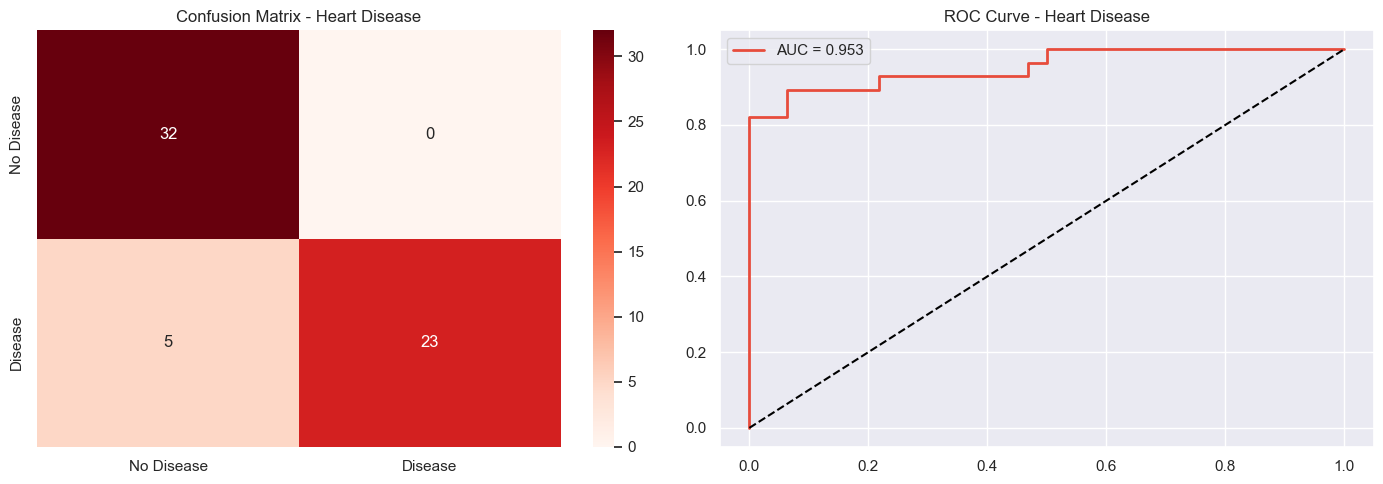

 Heart Disease model saved!


In [45]:
# ── Evaluation ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_h = confusion_matrix(y_test_h, best_heart_model.predict(X_test_h_sc))
sns.heatmap(cm_h, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
axes[0].set_title('Confusion Matrix - Heart Disease')

fpr_h, tpr_h, _ = roc_curve(y_test_h, best_heart_model.predict_proba(X_test_h_sc)[:,1])
auc_h = roc_auc_score(y_test_h, best_heart_model.predict_proba(X_test_h_sc)[:,1])
axes[1].plot(fpr_h, tpr_h, color='#e74c3c', lw=2, label=f'AUC = {auc_h:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve - Heart Disease')
axes[1].legend()
plt.tight_layout()
plt.show()

joblib.dump(best_heart_model, 'heart_model.pkl')
joblib.dump(scaler_h, 'heart_scaler.pkl')
joblib.dump(list(X_heart.columns), 'heart_features.pkl')
print(' Heart Disease model saved!')

## PART 3: BREAST CANCER PREDICTION

In [48]:
cancer_data = load_breast_cancer()
df_cancer = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df_cancer['target'] = cancer_data.target

print('Shape:', df_cancer.shape)
print('Classes:', cancer_data.target_names)
print('Target distribution:')
print(df_cancer['target'].value_counts())
df_cancer.head()

Shape: (569, 31)
Classes: ['malignant' 'benign']
Target distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


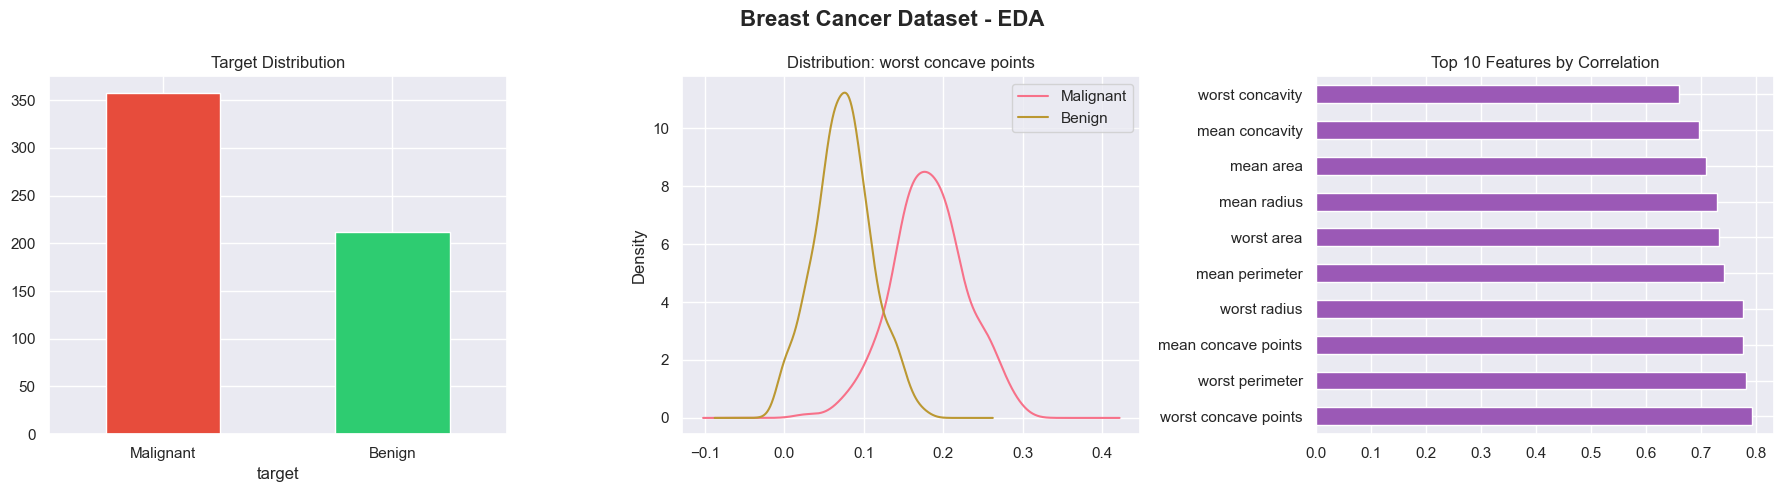

In [49]:
# ── EDA ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Breast Cancer Dataset - EDA', fontsize=16, fontweight='bold')

df_cancer['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'])
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['Malignant','Benign'], rotation=0)

top_features = df_cancer.corr()['target'].abs().sort_values(ascending=False).index[1:6]
df_cancer.groupby('target')[top_features[0]].plot(kind='kde', ax=axes[1])
axes[1].set_title(f'Distribution: {top_features[0][:20]}')
axes[1].legend(['Malignant','Benign'])

top_corr = df_cancer.corr()['target'].abs().sort_values(ascending=False)[1:11]
top_corr.plot(kind='barh', ax=axes[2], color='#9b59b6')
axes[2].set_title('Top 10 Features by Correlation')

plt.tight_layout()
plt.savefig('cancer_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# ── Preprocessing & Training ──
X_cancer = df_cancer.drop('target', axis=1)
y_cancer = df_cancer['target']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer)

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

models_cancer = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42)
}

results_cancer = {}
for name, model in models_cancer.items():
    model.fit(X_train_c_sc, y_train_c)
    acc = accuracy_score(y_test_c, model.predict(X_test_c_sc))
    auc = roc_auc_score(y_test_c, model.predict_proba(X_test_c_sc)[:,1])
    cv  = cross_val_score(model, X_train_c_sc, y_train_c, cv=5).mean()
    results_cancer[name] = {'Accuracy': acc, 'AUC': auc, 'CV Score': cv}
    print(f'{name:25s} | Acc: {acc:.4f} | AUC: {auc:.4f} | CV: {cv:.4f}')

best_cancer_name  = max(results_cancer, key=lambda k: results_cancer[k]['AUC'])
best_cancer_model = models_cancer[best_cancer_name]
print(f'\n Best Model: {best_cancer_name}')

Logistic Regression       | Acc: 0.9825 | AUC: 0.9954 | CV: 0.9802
Random Forest             | Acc: 0.9561 | AUC: 0.9939 | CV: 0.9538
Gradient Boosting         | Acc: 0.9561 | AUC: 0.9907 | CV: 0.9560
SVM                       | Acc: 0.9825 | AUC: 0.9950 | CV: 0.9714

 Best Model: Logistic Regression


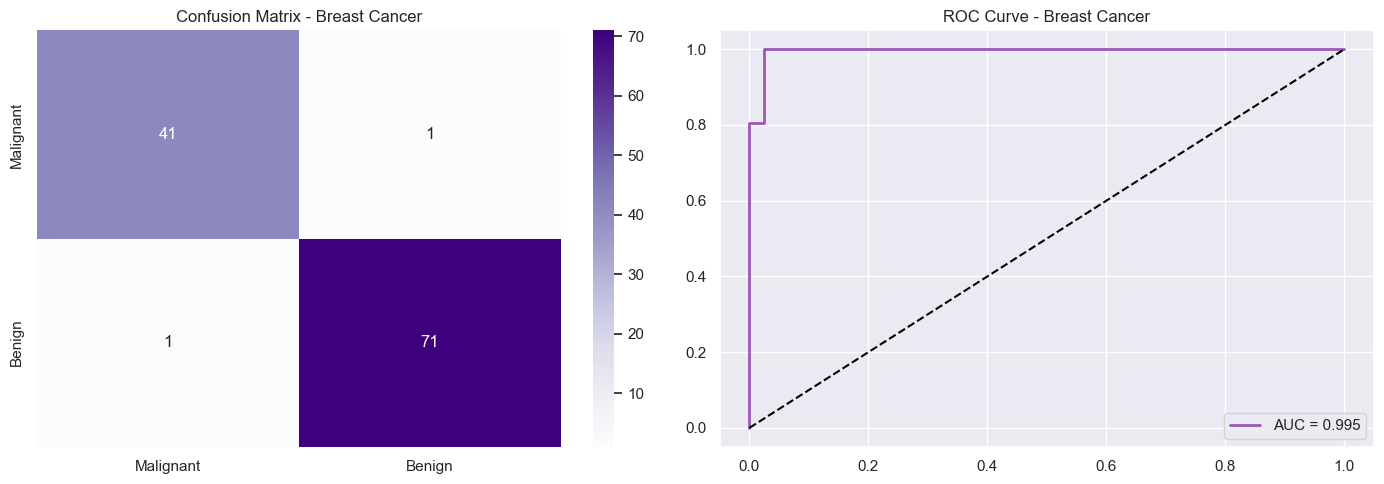

✅ Cancer model saved!


In [52]:
# ── Evaluation ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_c = confusion_matrix(y_test_c, best_cancer_model.predict(X_test_c_sc))
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Malignant','Benign'], yticklabels=['Malignant','Benign'])
axes[0].set_title('Confusion Matrix - Breast Cancer')

fpr_c, tpr_c, _ = roc_curve(y_test_c, best_cancer_model.predict_proba(X_test_c_sc)[:,1])
auc_c = roc_auc_score(y_test_c, best_cancer_model.predict_proba(X_test_c_sc)[:,1])
axes[1].plot(fpr_c, tpr_c, color='#9b59b6', lw=2, label=f'AUC = {auc_c:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve - Breast Cancer')
axes[1].legend()
plt.tight_layout()
plt.show()

joblib.dump(best_cancer_model, 'cancer_model.pkl')
joblib.dump(scaler_c, 'cancer_scaler.pkl')
joblib.dump(list(X_cancer.columns), 'cancer_features.pkl')
print('✅ Cancer model saved!')

## PART 4: MODEL COMPARISON SUMMARY

In [55]:
# ── Final Summary ──
summary = pd.DataFrame({
    'Disease':  ['Diabetes', 'Heart Disease', 'Breast Cancer'],
    'Best Model': [best_diab_name, best_heart_name, best_cancer_name],
    'Accuracy': [
        results_d[best_diab_name]['Accuracy'],
        results_heart[best_heart_name]['Accuracy'],
        results_cancer[best_cancer_name]['Accuracy']
    ],
    'AUC Score': [
        results_d[best_diab_name]['AUC'],
        results_heart[best_heart_name]['AUC'],
        results_cancer[best_cancer_name]['AUC']
    ]
})

summary['Accuracy'] = summary['Accuracy'].apply(lambda x: f'{x*100:.2f}%')
summary['AUC Score'] = summary['AUC Score'].apply(lambda x: f'{x:.4f}')
print('\n FINAL MODEL SUMMARY')
print('='*65)
print(summary.to_string(index=False))
print('='*65)
print('\n All models saved! Now run the Streamlit web app.')
print('   Command: streamlit run app.py')


 FINAL MODEL SUMMARY
      Disease          Best Model Accuracy AUC Score
     Diabetes   Gradient Boosting   75.97%    0.8304
Heart Disease Logistic Regression   91.67%    0.9531
Breast Cancer Logistic Regression   98.25%    0.9954

 All models saved! Now run the Streamlit web app.
   Command: streamlit run app.py
